In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/qingyi/wm811k-wafer-map/LSWMD.pkl


In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/qingyi/wm811k-wafer-map/LSWMD.pkl


In [4]:
import pandas as pd
df = pd.read_pickle('/kaggle/input/datasets/qingyi/wm811k-wafer-map/LSWMD.pkl')
print(df.shape)
print(df.columns.tolist())


(811457, 6)
['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']


In [5]:
import numpy as np

def unwrap(x):
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return None
        return str(x.flatten()[0])
    return x

df['label'] = df['failureType'].apply(unwrap)
print(df['label'].value_counts(dropna=False))

label
None         638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [6]:
labeled = df[df['label'].notna() & (df['label'] != 'none')].copy()
print(labeled.shape)   # ~25,519 rows, 8 classes


(25519, 7)


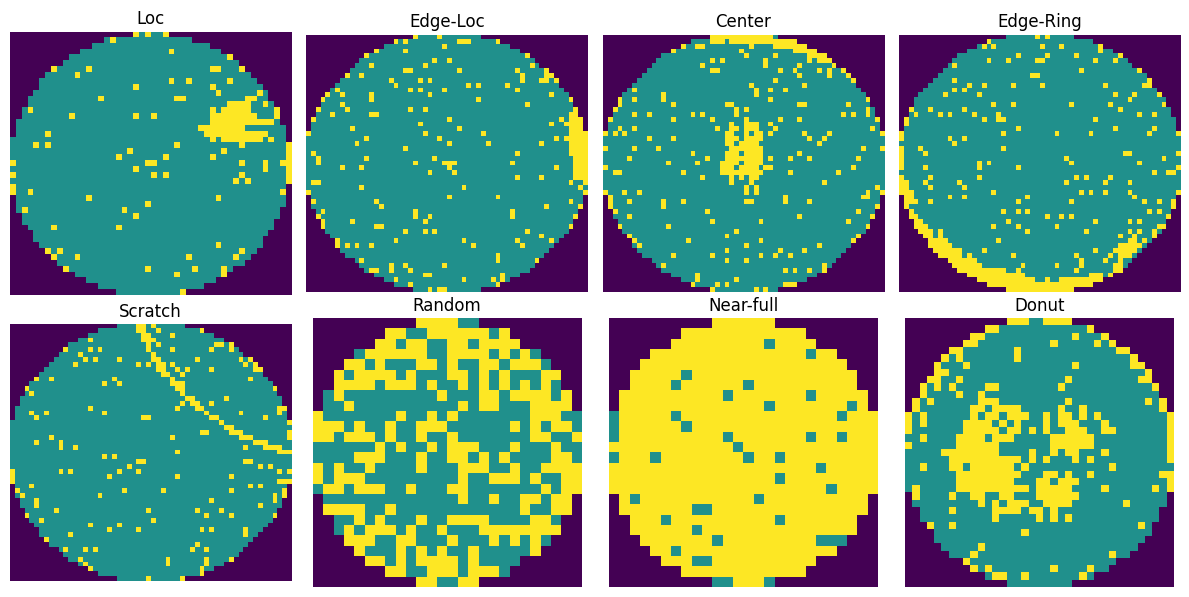

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, cls in zip(axes.flat, labeled['label'].unique()):
    wmap = labeled[labeled['label'] == cls]['waferMap'].iloc[0]
    ax.imshow(wmap)
    ax.set_title(cls); ax.axis('off')
plt.tight_layout(); plt.savefig('sample_maps.png', dpi=100); plt.show()

In [8]:
labeled['shape'] = labeled['waferMap'].apply(lambda x: x.shape)
print(labeled['shape'].nunique(), "distinct shapes")
print(labeled['waferMap'].apply(lambda x: x.shape[0]).describe())

329 distinct shapes
count    25519.000000
mean        43.151534
std         18.278374
min         22.000000
25%         31.000000
50%         39.000000
75%         52.000000
max        212.000000
Name: waferMap, dtype: float64


## Data Preparation

The 25,519 labeled wafer maps came in 329 distinct dimensions (from 22×22 up to
212×212), so each map was resized to a fixed 64×64 using nearest-neighbor
interpolation. Nearest-neighbor is deliberate: the pixel values are categorical
(0 = background, 1 = good die, 2 = defective die), not continuous intensities, so
bilinear interpolation would produce meaningless in-between values. Maps were
normalized to [0, 1] and given a single channel, yielding an input tensor of shape
(N, 64, 64, 1).

The train/test split (80/20, stratified) was performed **before** any class-imbalance
handling, so no information leaks from test into training. Stratification preserves
the class distribution across both splits. The dataset is severely imbalanced —
Edge-Ring has 9,680 samples versus 149 for Near-full, a 65:1 ratio — so balanced
class weights are applied during training, penalizing errors on rare classes in
proportion to their scarcity rather than duplicating or discarding data.

In [9]:
import cv2
import numpy as np

def resize_map(wmap, size=64):
    return cv2.resize(wmap.astype('uint8'), (size, size), interpolation=cv2.INTER_NEAREST)

labeled['resized'] = labeled['waferMap'].apply(resize_map)

In [10]:
X = np.stack(labeled['resized'].values).astype('float32') / 2.0
X = X[..., np.newaxis]   # add channel dim -> (N, 64, 64, 1)
print(X.shape)

(25519, 64, 64, 1)


In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y = le.fit_transform(labeled['label'].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)
print("classes:", list(le.classes_))

(20415, 64, 64, 1) (5104, 64, 64, 1)
classes: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']


In [12]:
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(0.7429039301310044), 1: np.float64(5.747466216216216), 2: np.float64(0.6147615032522283), 3: np.float64(0.32952931301652894), 4: np.float64(0.8879175365344467), 5: np.float64(21.444327731092436), 6: np.float64(3.6823593073593073), 7: np.float64(2.6721204188481678)}
